In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:44219")
client

<Client: 'tcp://127.0.0.1:44219' processes=9 threads=72, memory=136.41 GiB>

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import os.path as op
import tripyview as tpv
from xgcm.grid import Grid
import gsw
import matplotlib.pyplot as plt

# xr.set_options(keep_attrs=True)
# do_parallel       = True
# parallel_nprc     = 16   # number of dask workers
# parallel_nprc_bin = 8   # number of processor used to parallize the binning loop
# parallel_tmem     = 256   # max. available RAM

%matplotlib inline

/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages/tripyview/sub_data.py:8: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


/work/ba1254/b383315/conda/envs/fesom/lib/python3.12/site-packages


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
ddir = "/work/uo0119/a270067/runtime/awicm3-v3.1/"
sdir = "/scratch/b/b383315/fesom2/next/"
wdir = "/work/ba1254/b383315/fesom2/next/"

In [5]:
NXX = 50
ds1 = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/salt.fesom.2091.nc"
                              % NXX),
                     chunks={"nz1":4,"x":10000}
                    ).rename_dims({'x':'nod2'})
ds = xr.open_dataset(op.join(ddir,"N%2d/outdata/fesom/w.fesom.2091.nc"
                             % NXX),
                     chunks={"nz":4,"x":10000}
                    ).rename_dims({'x':'nod2'})

dz = xr.DataArray(np.diff(ds.nz), dims=["nz1"],
                  coords={"nz1":ds1.nz1}
                 )

ds1, ds

(<xarray.Dataset> Size: 29GB
 Dimensions:  (time: 12, nz1: 47, nod2: 12952215)
 Coordinates:
   * time     (time) datetime64[ns] 96B 2091-01-31T23:57:00 ... 2091-12-31T23:...
   * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
 Dimensions without coordinates: nod2
 Data variables:
     salt     (time, nz1, nod2) float32 29GB dask.array<chunksize=(1, 4, 10000), meta=np.ndarray>
 Attributes: (12/21)
     CDI:                                 Climate Data Interface version 2.2.4...
     Conventions:                         CF-1.6
     FESOM_model:                         FESOM2
     FESOM_website:                       fesom.de
     FESOM_git_SHA:                       e23bc823
     FESOM_MeshPath:                      /work/ab0995/a270067/fesom2/next/mesh/
     ...                                  ...
     FESOM_evp_rheol_steps:               120
     FESOM_opt_visc:                      7
     FESOM_use_wsplit:                    -1
     FESOM_autorotate_back_

In [6]:
dt = 180. # 3 minutes

mesh_path = '/work/ab0995/a270067/fesom2/next/mesh/'
mesh = tpv.load_mesh_fesom2(mesh_path, do_rot='None', focus=0, 
                            do_info=True, do_pickle=False
                           )

 > load mesh from *.out files: /work/ab0995/a270067/fesom2/next/mesh
 > load e_area from fesom.mesh.diag.nc
 > load n_area from fesom.mesh.diag.nc
 > compute lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_pbnd.shp
 > augment lsmask
 > save *.shp to /home/b/b383315/meshcache_tripyview/mesh/tripyview_fesom2_mesh_focus=0.shp
___FESOM2 MESH INFO________________________
 > path            = /work/ab0995/a270067/fesom2/next/mesh
 > id              = mesh
 > do rot          = None
 > [al,be,ga]      = 50, 15, -90
 > do augmpbnd     = True
 > do cavity       = False
 > do lsmask       = True
 > do earea,eresol = True, False
 > do narea,nresol = True, False
___________________________________________
 > #node           = 12952215
 > #elem           = 25742475
 > #lvls           = 48
___________________________________________


In [7]:
diag = xr.open_dataset(op.join(mesh_path, 'fesom.mesh.diag.nc'),
                       chunks={'nz':1,"nz1":1,'elem':200000,
                               'nod2':100000,'edg_n':300000}
                      )

area = xr.DataArray(.5*(diag.nod_area.isel(nz=0).data
                        + diag.nod_area.isel(nz=1).data
                       ),
                    dims=ds1.salt.isel(time=0,nz1=0).dims, 
                    coords=ds1.salt.isel(time=0,nz1=0).coords
                   ).chunk(ds1.salt.isel(time=0,nz1=0).chunks
                          )
area3 = xr.DataArray(diag.nod_area.isel(nz=4).data,
                     dims=ds1.salt.isel(time=0,nz1=0).dims, 
                     coords=ds1.salt.isel(time=0,nz1=0).coords
                    ).chunk(ds1.salt.isel(time=0,nz1=0).chunks
                           )
area.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))
area3.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))

depth = diag.zbar_n_bottom.load()
depth.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))

diag.nz, area, area3

(<xarray.DataArray 'nz' (nz: 48)> Size: 384B
 array([ 0.00e+00, -5.00e+00, -1.00e+01, -2.00e+01, -3.00e+01, -4.00e+01,
        -5.00e+01, -6.00e+01, -7.00e+01, -8.00e+01, -9.00e+01, -1.00e+02,
        -1.15e+02, -1.35e+02, -1.60e+02, -1.90e+02, -2.30e+02, -2.80e+02,
        -3.40e+02, -4.10e+02, -4.90e+02, -5.80e+02, -6.80e+02, -7.90e+02,
        -9.10e+02, -1.04e+03, -1.18e+03, -1.33e+03, -1.50e+03, -1.70e+03,
        -1.92e+03, -2.15e+03, -2.40e+03, -2.65e+03, -2.90e+03, -3.15e+03,
        -3.40e+03, -3.65e+03, -3.90e+03, -4.15e+03, -4.40e+03, -4.65e+03,
        -4.90e+03, -5.15e+03, -5.40e+03, -5.65e+03, -6.00e+03, -6.25e+03])
 Coordinates:
   * nz       (nz) float64 384B 0.0 -5.0 -10.0 ... -5.65e+03 -6e+03 -6.25e+03
 Attributes:
     long_name:  depth of levels,
 <xarray.DataArray 'mul-e1fb4e8ee0ba019de543d57e67be9ee5' (nod2: 12952215)> Size: 104MB
 dask.array<rechunk-merge, shape=(12952215,), dtype=float64, chunksize=(10000,), chunktype=numpy.ndarray>
 Coordinates:
     time     d

In [8]:
# area = xr.DataArray(.5*(diag.nod_area.isel(nz=slice(None,-1)).data
#                         + diag.nod_area.isel(nz=slice(1,None)).data
#                        ),
#                     dims=ds1.salt.isel(time=0).dims, 
#                     coords=ds1.salt.isel(time=0).coords
#                    ).chunk(ds1.salt.isel(time=0).chunks)
# Vol = area * dz
# print(Vol)
# Vol.to_dataset(name="vol").to_zarr(op.join(wdir,"volume/nod2.zarr"),
#                                    mode="w")

Vol = xr.open_zarr(op.join(wdir,"volume/nod2.zarr")
                  ).rename_dims({"x":"nod2"}).vol
Vol

<xarray.DataArray 'vol' (nz1: 47, nod2: 12952215)> Size: 5GB
dask.array<open_dataset-vol, shape=(47, 12952215), dtype=float64, chunksize=(4, 10000), chunktype=numpy.ndarray>
Coordinates:
    time     datetime64[ns] 8B ...
  * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
Dimensions without coordinates: nod2

In [9]:
plt_contb = False        # background contour line (thin)
plt_contf = False       # contour line of main colorbar steps 
plt_contr = False       # contour line of reference value 
plt_contl = False       # label contourline of main colorbar steps 
do_plt = 'tpc'          # plot pcolor (tpc) or contourf (tcf)
box = [-180, 180, -90, 90] # regional limitation of plot. [lonmin, lonmax, latmin, latmax]
proj = 'rob'               # Robinson projection
# proj = 'sps'               # SouthPolarStereo projection
do_rescale = None          # rescale data: None, 'log10', 'slog10', np.array(...)
nrow0 = 1                  # int, (default: 1) number of columns when plotting multiple data panels
ncol0 = 1                  # int, (default: 1) number of rows when plotting multiple data panels
do_enum = False            # bool, (default: False) do enumeration of axes with a), b), c) …
cbl_opt = dict()           # dict, (default: dict()) direct option for colorbar labels (fontsize, fontweight, …) via kwarg
cbtl_opt = dict()          # dict, (default: dict()) direct option for colorbar tick labels (fontsize, fontweight, …) via kwarg
save_dpi = 500

# cstr      = 'matplotlib.RdBu_r'
# cnum      = 30
# cref      = 0
crange    = None
cfac      = None
climit    = None
chist     = True
ctresh    = 0.995

# cb_label = "DS05 - clim salt annual"
cstr      = 'matplotlib.RdBu_r'
# cstr      = 'cmocean.balance'
cnum      = 41
cref      = 0.
cmin      = -1e-6
cmax      = 1e-6

cinfo = tpv.set_cinfo(cstr, cnum, crange, cmin, cmax, 
                      cref, cfac, climit, chist, ctresh
                     ) 

In [10]:
maskSS = xr.DataArray(ds1.salt.where(ds1.salt>0.).isel(time=0).to_masked_array().mask,
                     dims=ds1.salt.isel(time=0).dims,
                     coords=ds1.salt.isel(time=0).coords
                    ).chunk(ds1.salt.isel(time=0).chunks)
maskS = xr.open_zarr(op.join(sdir,"salt-mask_%4d.zarr" 
                             % (2091))
                    ).mask
maskS

<xarray.DataArray 'mask' (time: 12, nz1: 47, nod2: 12952215)> Size: 7GB
dask.array<open_dataset-mask, shape=(12, 47, 12952215), dtype=bool, chunksize=(1, 4, 10000), chunktype=numpy.ndarray>
Coordinates:
  * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
  * time     (time) datetime64[ns] 96B 2091-01-31T23:57:00 ... 2091-12-31T23:...
Dimensions without coordinates: nod2

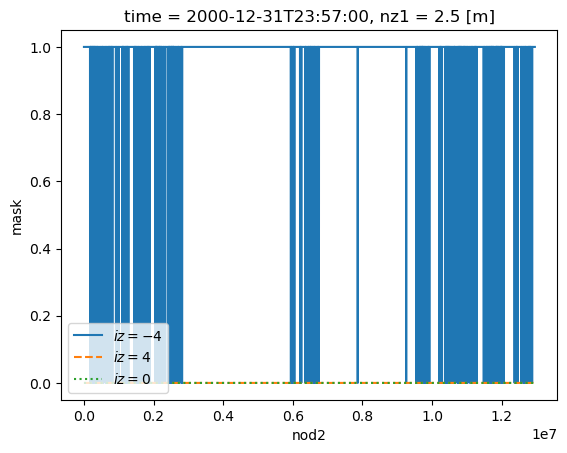

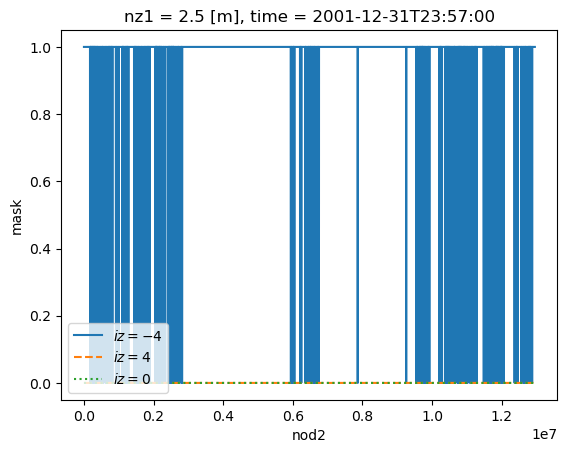

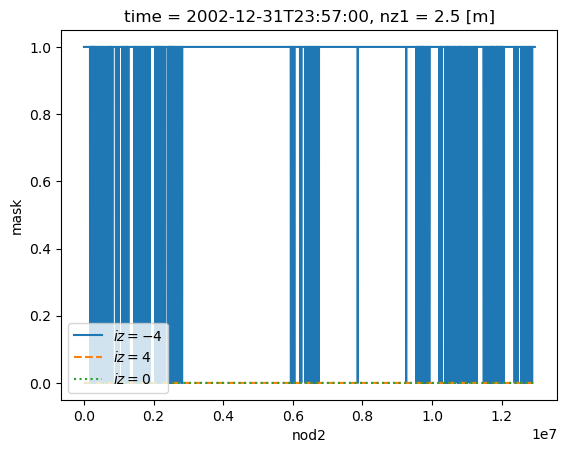

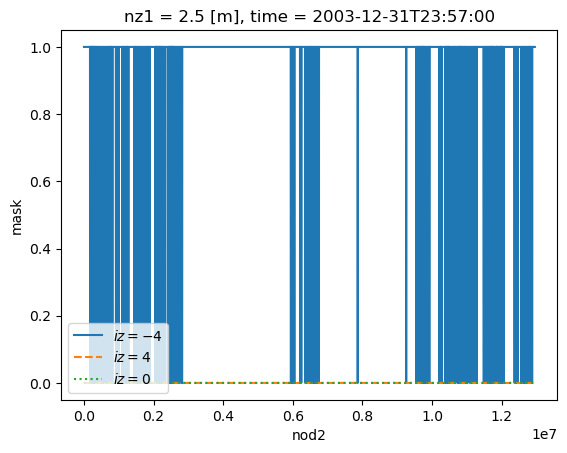

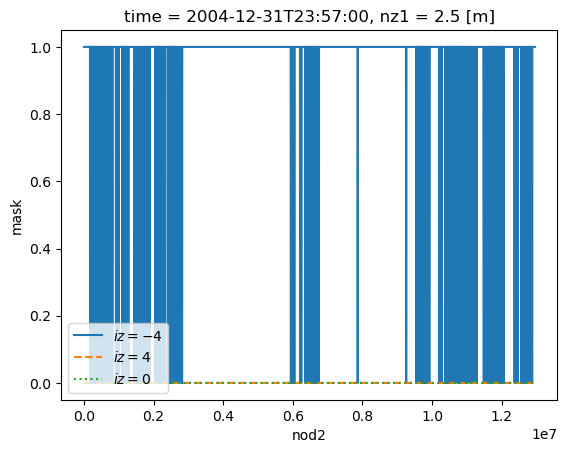

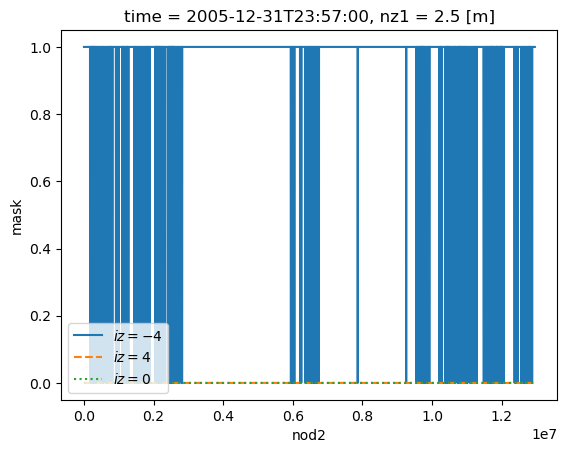

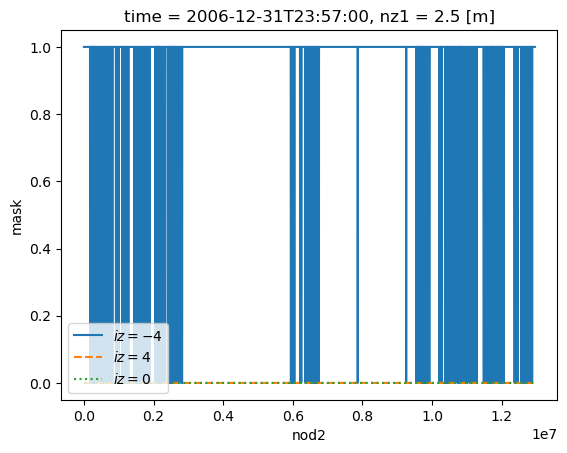

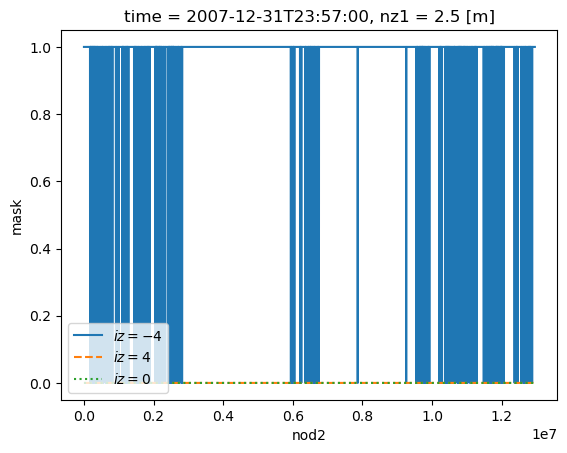

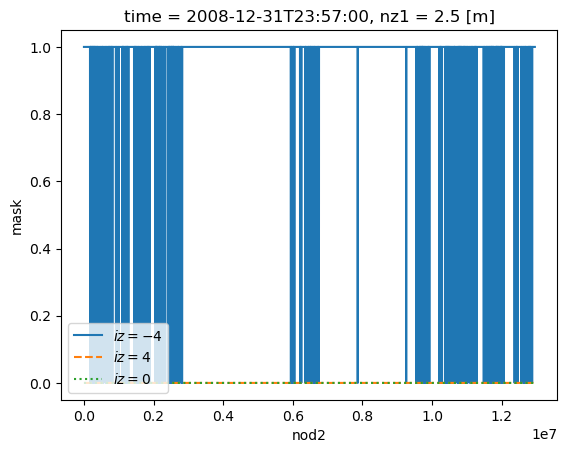

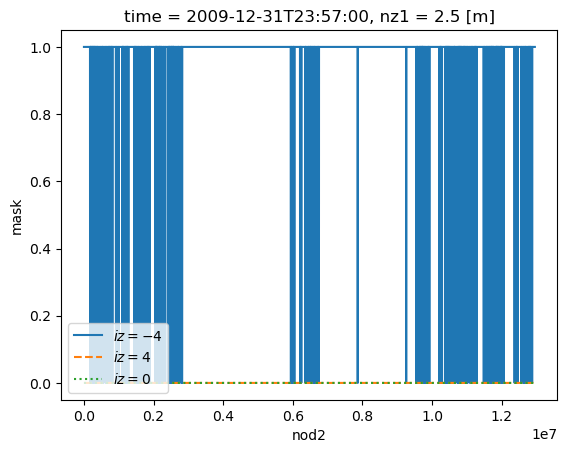

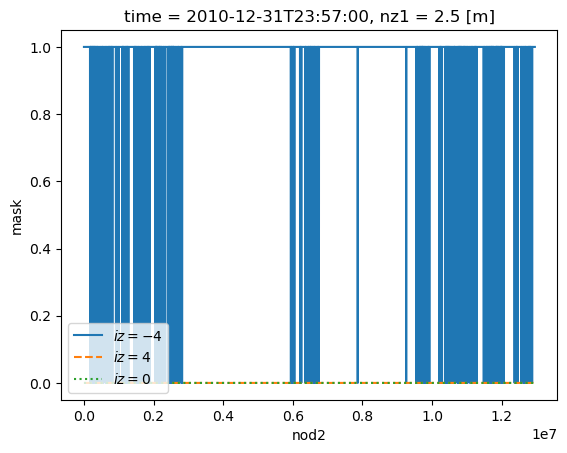

In [10]:
for yy in range(2000,2011):
    maskS = xr.open_zarr(op.join(sdir,"salt-mask_%4d.zarr" 
                                 % (yy))
                        ).mask
    fig, ax = plt.subplots()
    maskS.isel(time=0,nz1=-4).plot(ax=ax, label=r"$iz=-4$")
    maskS.isel(time=4,nz1=4).plot(ax=ax, ls="--", label=r"$iz=4$")
    maskS.isel(time=-1,nz1=0).plot(ax=ax, ls=":", label=r"$iz=0$")
    ax.legend(loc="lower left")
    plt.show()

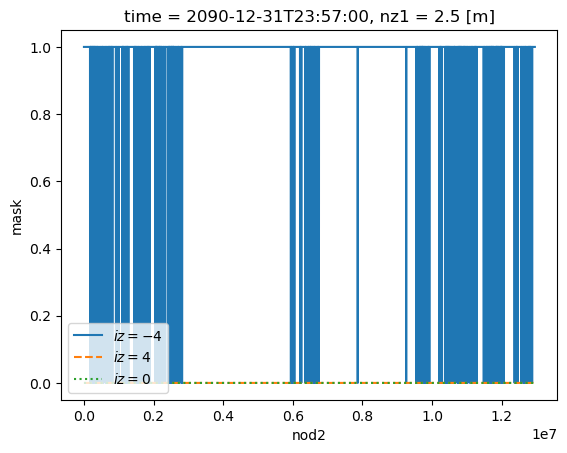

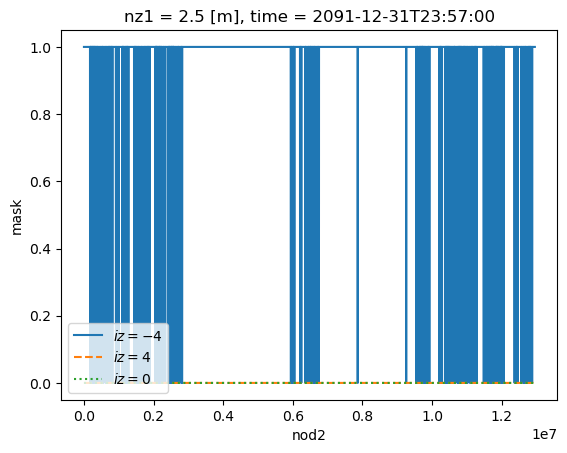

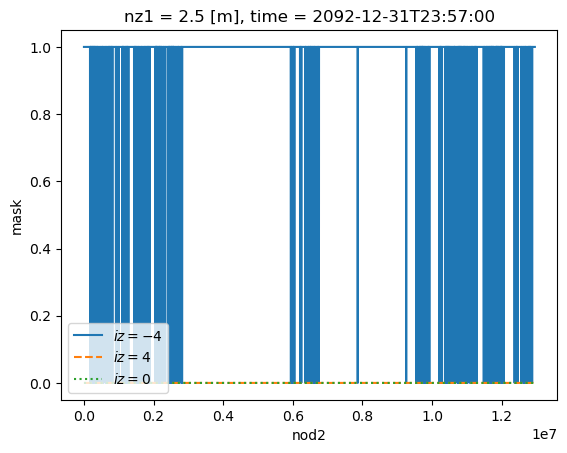

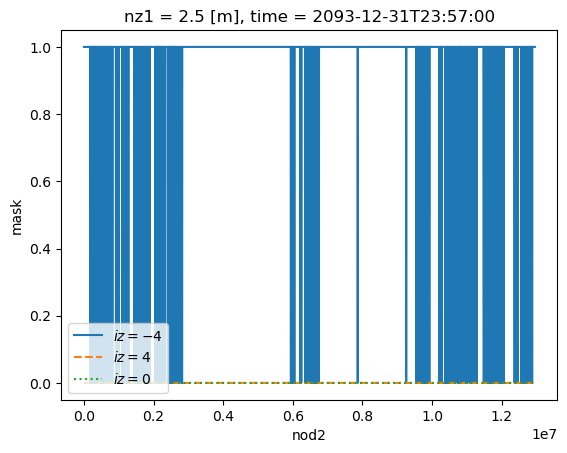

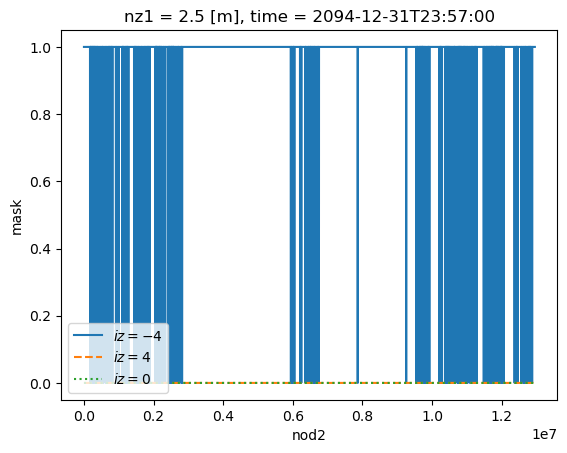

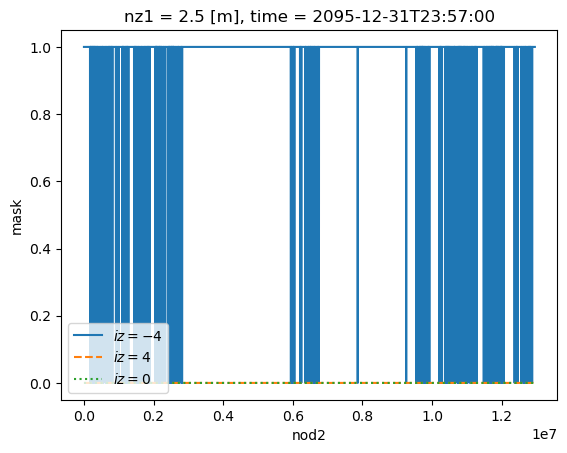

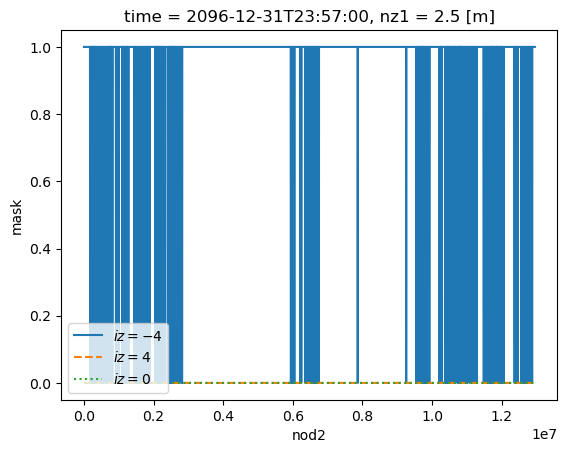

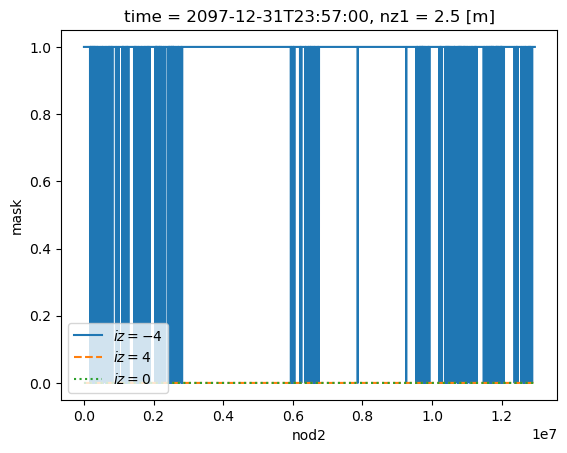

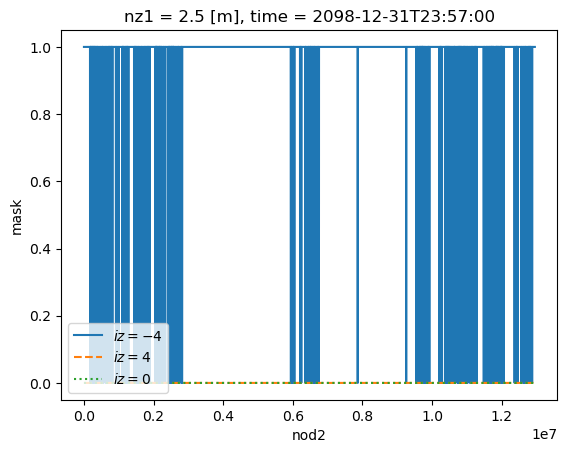

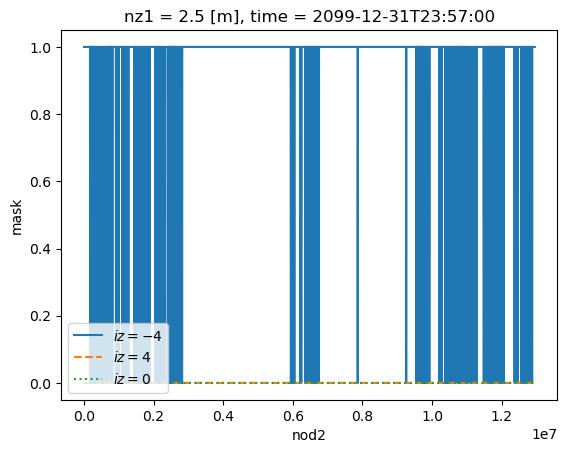

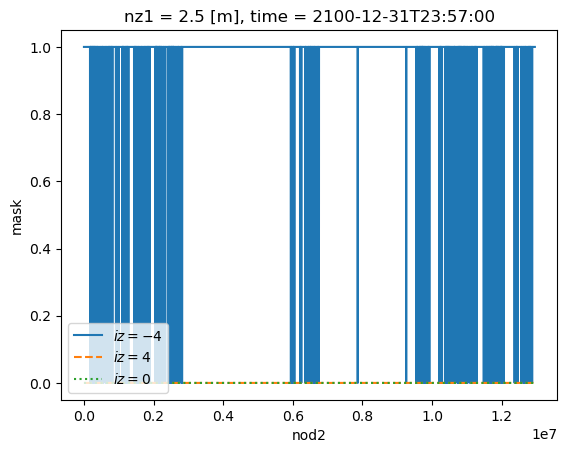

In [11]:
for yy in range(2090,2101):
    maskS = xr.open_zarr(op.join(sdir,"salt-mask_%4d.zarr" 
                                 % (yy))
                        ).mask
    fig, ax = plt.subplots()
    maskS.isel(time=0,nz1=-4).plot(ax=ax, label=r"$iz=-4$")
    maskS.isel(time=4,nz1=4).plot(ax=ax, ls="--", label=r"$iz=4$")
    maskS.isel(time=-1,nz1=0).plot(ax=ax, ls=":", label=r"$iz=0$")
    ax.legend(loc="lower left")
    plt.show()

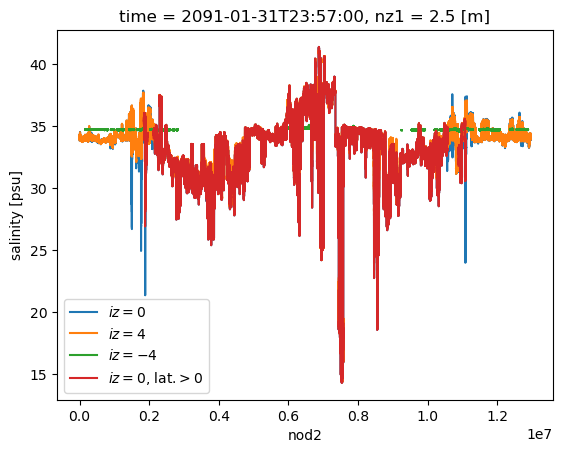

In [26]:
fig, ax = plt.subplots()
ds1.salt.where(~maskS).isel(time=0,nz1=0).plot(ax=ax, label=r"$iz=0$")
ds1.salt.where(~maskS).isel(time=0,nz1=4).plot(ax=ax, label=r"$iz=4$")
ds1.salt.where(~maskS).isel(time=0,nz1=-4).plot(ax=ax, label=r"$iz=-4$")
ds1.salt.where(~maskS).where(diag.lat>0.).isel(time=0,nz1=0).plot(ax=ax, label=r"$iz=0$, lat.$>0$")
ax.legend(loc="lower left")

In [ ]:
# we, ea, so, no = (-80,-60,31,45)   # GulfStrEx
# we, ea, so, no = (130,150,31,45)   # KuroEx
we, ea, so, no = (-75,-45,-65,-55) # DrakePass
# we, ea, so, no = (-45,-35,10,25)   # Agulhas

fig, ax = plt.subplots()
ds1.salt.where(~maskS).where((diag.lat>so)
                             & (diag.lat<no)
                             & (diag.lon<ea)
                             & (diag.lon>we)
                            ).isel(time=0,nz1=0).plot(ax=ax,label=r"$iz=0$")
ds1.salt.where(~maskS).where((diag.lat>so)
                             & (diag.lat<no)
                             & (diag.lon<ea)
                             & (diag.lon>we)
                            ).isel(time=0,nz1=10).plot(ax=ax,label=r"$iz=10$")
ax.legend(loc="lower right")

In [ ]:
ystart = 2000
NXX = 48
months = range(12)

for yy in range(ystart,2011):
    
    s_path = op.join(ddir,'N%02d/outdata/fesom/salt.fesom.%4d.nc'
                     % (NXX,yy))
    salt = xr.open_dataset(s_path, chunks={"time":-1,"nz1":1,"x":10000}
                          ).rename_dims({'x':'nod2'}).salt
    
    for mm in months:
        if mm == 0:
            maskS = xr.DataArray(salt.where(salt>0.).isel(time=mm).to_masked_array().mask,
                                 dims=salt.isel(time=mm).dims, 
                                 coords=salt.isel(time=mm).coords
                                ).chunk(salt.isel(time=mm).chunks)
        else:
            maskS = xr.concat([maskS,
                               xr.DataArray(salt.where(salt>0.).isel(time=mm).to_masked_array().mask,
                                 dims=salt.isel(time=mm).dims, 
                                 coords=salt.isel(time=mm).coords
                                ).chunk(salt.isel(time=mm).chunks)
                              ], "time")
    # maskS = xr.DataArray(salt.where(salt>0.).mean("time").to_masked_array().mask,
    #                      dims=salt.isel(time=0).dims, 
    #                      coords=salt.isel(time=0).coords
    #                     ).chunk(salt.isel(time=0).chunks)
    
    dsave = maskS.to_dataset(name="mask")
    print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(sdir,"salt-mask_%4d.zarr" 
                                                  % (yy)),
                                          mode="w")
    dsave.close()
    del salt
    print(yy)

In [ ]:
ystart = 2090
NXX = 50
months = range(12)

for yy in range(ystart,2101):
    
    s_path = op.join(ddir,'N%02d/outdata/fesom/salt.fesom.%4d.nc'
                     % (NXX,yy))
    salt = xr.open_dataset(s_path, chunks={"time":-1,"nz1":1,"x":10000}
                          ).rename_dims({'x':'nod2'}).salt
    
    for mm in months:
        if mm == 0:
            maskS = xr.DataArray(salt.where(salt>0.).isel(time=mm).to_masked_array().mask,
                                 dims=salt.isel(time=mm).dims, 
                                 coords=salt.isel(time=mm).coords
                                ).chunk(salt.isel(time=mm).chunks)
        else:
            maskS = xr.concat([maskS,
                               xr.DataArray(salt.where(salt>0.).isel(time=mm).to_masked_array().mask,
                                 dims=salt.isel(time=mm).dims, 
                                 coords=salt.isel(time=mm).coords
                                ).chunk(salt.isel(time=mm).chunks)
                              ], "time")
    # maskS = xr.DataArray(salt.where(salt>0.).mean("time").to_masked_array().mask,
    #                      dims=salt.isel(time=0).dims, 
    #                      coords=salt.isel(time=0).coords
    #                     ).chunk(salt.isel(time=0).chunks)
    
    dsave = maskS.to_dataset(name="mask")
    print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(sdir,"salt-mask_%4d.zarr" 
                                                  % (yy)),
                                          mode="w")
    dsave.close()
    del salt
    print(yy)

<xarray.DataArray (time: 12)> Size: 96B
dask.array<truediv, shape=(12,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 96B 2000-01-31T23:57:00 ... 2000-12-31T23:... <xarray.DataArray 'vol' (nz1: 47, nod2: 12952215, time: 12)> Size: 58GB
dask.array<where, shape=(47, 12952215, 12), dtype=float64, chunksize=(4, 10000, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 96B 2000-01-31T23:57:00 ... 2000-12-31T23:...
  * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
Dimensions without coordinates: nod2


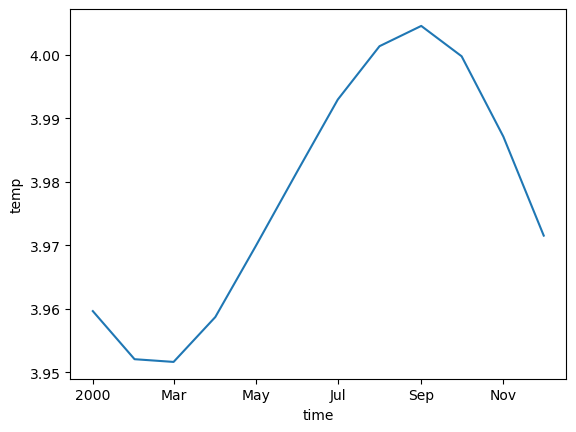

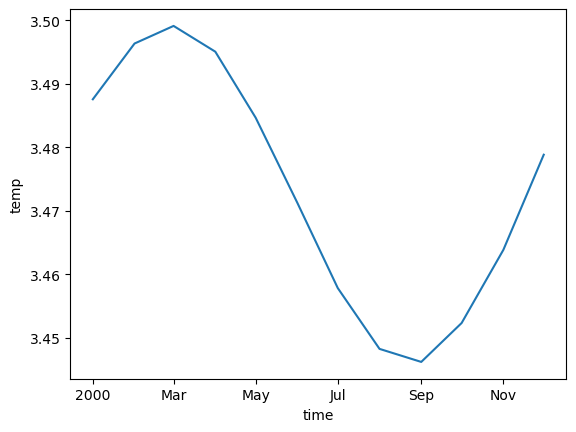

2000
<xarray.DataArray (time: 12)> Size: 96B
dask.array<truediv, shape=(12,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 96B 2001-01-31T23:57:00 ... 2001-12-31T23:... <xarray.DataArray 'vol' (nz1: 47, nod2: 12952215, time: 12)> Size: 58GB
dask.array<where, shape=(47, 12952215, 12), dtype=float64, chunksize=(4, 10000, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 96B 2001-01-31T23:57:00 ... 2001-12-31T23:...
  * nz1      (nz1) float64 376B 2.5 7.5 15.0 ... 5.525e+03 5.825e+03 6.125e+03
Dimensions without coordinates: nod2
2001
<xarray.DataArray (time: 12)> Size: 96B
dask.array<truediv, shape=(12,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 96B 2002-01-31T23:57:00 ... 2002-12-31T23:... <xarray.DataArray 'vol' (nz1: 47, nod2: 12952215, time: 12)> Size: 58GB
dask.array<where, shape=(47, 12952215, 12), dtype=float64, chunksize=(4, 10000, 1

In [10]:
ystart = 2000
NXX = 48
months = range(12)

for yy in range(ystart,2011):
    
    t_path = op.join(ddir,'N%02d/outdata/fesom/temp.fesom.%4d.nc'
                     % (NXX,yy))
    temp = xr.open_dataset(t_path, chunks={"time":1,"nz1":4,"x":10000}
                          ).rename_dims({'x':'nod2'}).temp
    
    maskS = xr.open_zarr(op.join(sdir,"salt-mask_%4d.zarr" 
                                 % (yy))
                        ).mask
    sVol = Vol.where(~maskS)
#     mld = tpv.load_data_fesom2(mesh, h_path, do_filename=True,
#                               vname="MLD3", do_info=False,
#                               year=2000, mon=1
#                              ).chunk({'nod2':100000})
    # area = xr.DataArray(.5*(diag.nod_area.isel(nz=slice(None,-1)).data
    #                         + diag.nod_area.isel(nz=slice(1,None)).data
    #                        ),
    #                     dims=salt.isel(time=0).dims, 
    #                     coords=salt.isel(time=0).coords
    #                    ).chunk(salt.isel(time=0).chunks)
            # ke.coords["nz1"] = ("nz1",dz.nz1.data)
        
    # for mm in months:
        
#         for i in range(len(ds1.nz1)):
#             if i == 0:
#                 temp = tpv.load_data_fesom2(mesh, t_path, do_filename=True,
#                                           vname="temp", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                 salt = tpv.load_data_fesom2(mesh, s_path, do_filename=True,
#                                           vname="salt", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                 unod = tpv.load_data_fesom2(mesh, u_path, do_filename=True,
#                                           vname="unod", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                 vnod = tpv.load_data_fesom2(mesh, v_path, do_filename=True,
#                                           vname="vnod", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#             else:
#                 temp = xr.concat([temp,
#                                   tpv.load_data_fesom2(mesh, t_path, do_filename=True,
#                                           vname="temp", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                                  ], "nz1")
#                 salt = xr.concat([salt,
#                                   tpv.load_data_fesom2(mesh, s_path, do_filename=True,
#                                           vname="salt", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                                  ], "nz1")
#                 unod = xr.concat([unod,
#                                   tpv.load_data_fesom2(mesh, u_path, do_filename=True,
#                                           vname="unod", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                                  ], "nz1")
#                 vnod = xr.concat([vnod,
#                                   tpv.load_data_fesom2(mesh, v_path, do_filename=True,
#                                           vname="vnod", do_info=False,
#                                           depth=[ds1.nz1[i].values], year=yy, mon=mm
#                                          ).chunk({'nod2':100000})
#                                  ], "nz1")
                
#         temp.coords["nz1"] = ("nz1",dz.nz1.data)
#         salt.coords["nz1"] = ("nz1",dz.nz1.data)
#         ke = .5*(unod**2 + vnod**2)
#             # ke.coords["nz1"] = ("nz1",dz.nz1.data)
        
        # if mm == 0:
        #     print(temp.where(~maskS), sVol)
    tave = ((temp.where(~maskS) * sVol).where(diag.lat>0.).sum(["nz1","nod2"],skipna=True)
            / sVol.where(diag.lat>0.).sum(["nz1","nod2"],skipna=True)
           )
    print(tave, sVol)
        # else:
        #     tave = xr.concat([tave, 
        #                       ((temp.where(~maskS) * sVol).isel(time=mm).sum(skipna=True)
        #                        / sVol.isel(time=mm).sum(skipna=True).compute()
        #                       )], "time")
    
    dsave = tave.chunk({"time":-1}).to_dataset(name="temp")
    dsave.coords["time"] = ("time", np.arange(str(yy), str(yy+1), 
                                              dtype='datetime64[M]'))
    if yy == ystart:
        fig, ax = plt.subplots()
        dsave.temp.plot(ax=ax)
        plt.show()
    # print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(wdir,"glob-ave/N%2d/T-north_%4d.zarr" 
                                                  % (NXX,yy)),
                                          mode="w")
    dsave.close()
    
    tave = ((temp.where(~maskS) * sVol).where(diag.lat<0.).sum(["nz1","nod2"],skipna=True)
            / sVol.where(diag.lat<0.).sum(["nz1","nod2"],skipna=True)
           )
    # print(tave, sVol)
        # else:
        #     tave = xr.concat([tave, 
        #                       ((temp.where(~maskS) * sVol).isel(time=mm).sum(skipna=True)
        #                        / sVol.isel(time=mm).sum(skipna=True).compute()
        #                       )], "time")
    
    dsave = tave.chunk({"time":-1}).to_dataset(name="temp")
    dsave.coords["time"] = ("time", np.arange(str(yy), str(yy+1), 
                                              dtype='datetime64[M]'))
    if yy == ystart:
        fig, ax = plt.subplots()
        dsave.temp.plot(ax=ax)
        plt.show()
    # print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(wdir,"glob-ave/N%2d/T-south_%4d.zarr" 
                                                  % (NXX,yy)),
                                          mode="w")
    dsave.close()
    print(yy)

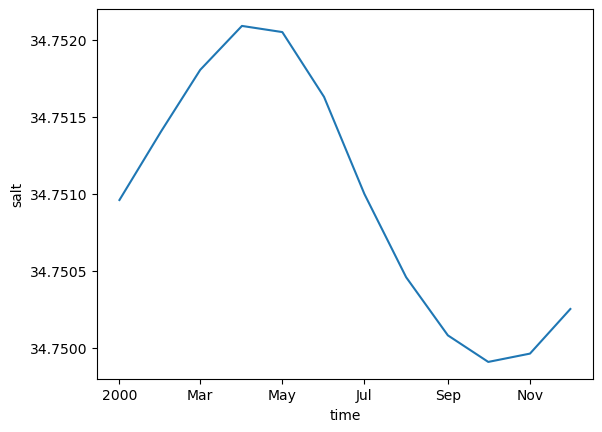

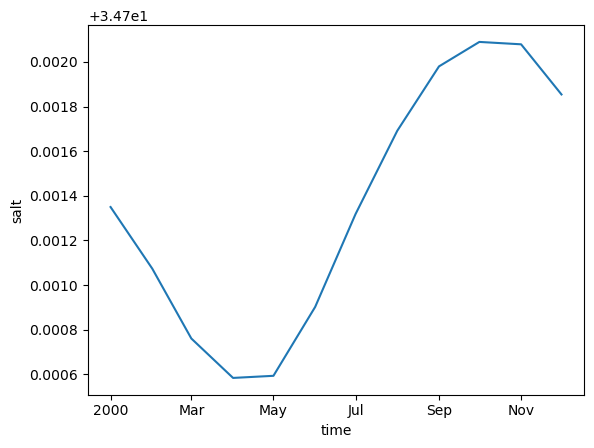

2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010


In [9]:
ystart = 2000
NXX = 48
months = range(12)

for yy in range(ystart,2011):
    
    s_path = op.join(ddir,'N%02d/outdata/fesom/salt.fesom.%4d.nc'
                     % (NXX,yy))
    salt = xr.open_dataset(s_path, chunks={"time":1,"nz1":4,"x":10000}
                          ).rename_dims({'x':'nod2'}).salt
    
    maskS = xr.open_zarr(op.join(sdir,"salt-mask_%4d.zarr" 
                                 % (yy))
                        ).mask
    sVol = Vol.where(~maskS)
        
    # for mm in months:
    #     if mm == 0:
    save = ((salt.where(~maskS) * sVol).where(diag.lat>0.).sum(["nz1","nod2"],skipna=True)
            / sVol.where(diag.lat>0.).sum(["nz1","nod2"],skipna=True)
           )
        # else:
        #     save = xr.concat([save, 
        #                       ((salt.where(~maskS) * sVol).isel(time=mm).sum(skipna=True)
        #                        / sVol.isel(time=mm).sum(skipna=True).compute()
        #                       )], "time")
    
    dsave = save.chunk({"time":-1}).to_dataset(name="salt")
    dsave.coords["time"] = ("time", np.arange(str(yy), str(yy+1), 
                                              dtype='datetime64[M]'))
    if yy == ystart:
        fig, ax = plt.subplots()
        dsave.salt.plot(ax=ax)
        plt.show()
    # print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(wdir,"glob-ave/N%2d/S-north_%4d.zarr" 
                                                  % (NXX,yy)),
                                          mode="w")
    dsave.close()
    
    save = ((salt.where(~maskS) * sVol).where(diag.lat<0.).sum(["nz1","nod2"],skipna=True)
            / sVol.where(diag.lat<0.).sum(["nz1","nod2"],skipna=True)
           )
        # else:
        #     save = xr.concat([save, 
        #                       ((salt.where(~maskS) * sVol).isel(time=mm).sum(skipna=True)
        #                        / sVol.isel(time=mm).sum(skipna=True).compute()
        #                       )], "time")
    
    dsave = save.chunk({"time":-1}).to_dataset(name="salt")
    dsave.coords["time"] = ("time", np.arange(str(yy), str(yy+1), 
                                              dtype='datetime64[M]'))
    if yy == ystart:
        fig, ax = plt.subplots()
        dsave.salt.plot(ax=ax)
        plt.show()
    # print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(wdir,"glob-ave/N%2d/S-south_%4d.zarr" 
                                                  % (NXX,yy)),
                                          mode="w")
    dsave.close()
    print(yy)

In [10]:
ystart = 2007
NXX = 48
months = range(12)

for yy in range(ystart,2008):
    
    u_path = op.join(ddir,'N%02d/outdata/fesom/unod.fesom.%4d.nc'
                     % (NXX,yy))
    v_path = op.join(ddir,'N%02d/outdata/fesom/vnod.fesom.%4d.nc'
                     % (NXX,yy))
    h_path = op.join(ddir,'N%02d/outdata/fesom/MLD3.fesom.%4d.nc'
                     % (NXX,yy))
    unod = xr.open_dataset(u_path, chunks={"time":1,"nz1":4,"x":10000}
                          ).rename_dims({'x':'nod2'}).unod
    vnod = xr.open_dataset(v_path, chunks={"time":1,"nz1":4,"x":10000}
                          ).rename_dims({'x':'nod2'}).vnod
    mld  = xr.open_dataset(h_path, chunks={"time":1,"x":10000}
                          ).rename_dims({'x':'nod2'}).MLD3
    
    maskS = xr.open_zarr(op.join(sdir,"salt-mask_%4d.zarr" 
                                 % (yy))
                        ).mask
    sVol = Vol.where(~maskS)
    
    ke = .5*(unod**2 + vnod**2)

    # for mm in months:
    #     if mm == 0:
    kave = ((ke.where(~maskS) * sVol
            ).where(ke.nz1<np.abs(mld)
                   ).where(diag.lat>0.).sum(["nz1","nod2"],skipna=True)
            / sVol.where(sVol.nz1<np.abs(mld)
                        ).where(diag.lat>0.).sum(["nz1","nod2"],skipna=True)
           )
        # else:
        #     kave = xr.concat([kave, 
        #                       ((ke.where(~maskS) * sVol
        #                        ).where(ke.nz1<np.abs(mld.isel(time=mm))
        #                               ).isel(time=mm).sum(skipna=True)
        #                        / sVol.where(sVol.nz1<np.abs(mld)
        #                                    ).isel(time=mm).sum(skipna=True).compute()
        #                       )], "time")
    
    dsave = kave.chunk({"time":-1}).to_dataset(name="KE")
    dsave.coords["time"] = ("time", np.arange(str(yy), str(yy+1), 
                                              dtype='datetime64[M]'))
    # if yy == ystart:
    #     fig, ax = plt.subplots()
    #     dsave.KE.plot(ax=ax)
    #     plt.show()
    # # print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(wdir,"glob-ave/N%2d/KE-north-mld_%4d.zarr" 
                                                  % (NXX,yy)),
                                          mode="w")
    dsave.close()
    
    kave = ((ke.where(~maskS) * sVol
            ).where(ke.nz1<np.abs(mld)
                   ).where(diag.lat<0.).sum(["nz1","nod2"],skipna=True)
            / sVol.where(sVol.nz1<np.abs(mld)
                        ).where(diag.lat<0.).sum(["nz1","nod2"],skipna=True)
           )
    
    dsave = kave.chunk({"time":-1}).to_dataset(name="KE")
    dsave.coords["time"] = ("time", np.arange(str(yy), str(yy+1), 
                                              dtype='datetime64[M]'))
    # if yy == ystart:
    #     fig, ax = plt.subplots()
    #     dsave.KE.plot(ax=ax)
    #     plt.show()
    # # print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(wdir,"glob-ave/N%2d/KE-south-mld_%4d.zarr" 
                                                  % (NXX,yy)),
                                          mode="w")
    dsave.close()
    print(yy)

2007


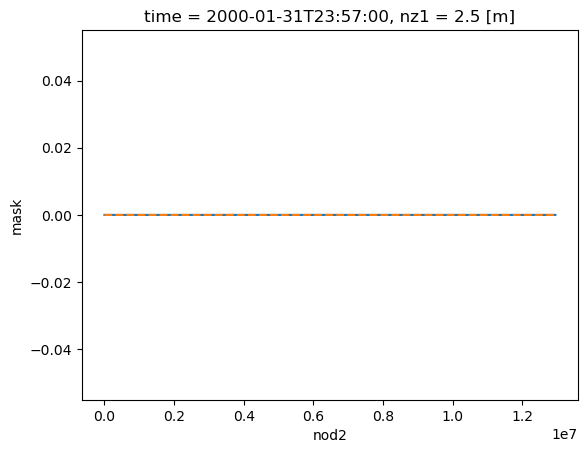

In [16]:
# ke.shape, maskS.isel(nz1=0).reset_coords(drop=True).shape
maskS = xr.open_zarr(op.join(sdir,"salt-mask_%4d.zarr" 
                             % (2000))
                    ).mask.isel(nz1=0)
maskS.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))

fig, ax = plt.subplots()
xr.DataArray(maskS.where(maskS==0.).mean("time").to_masked_array().mask,
             dims=maskS.isel(time=0).dims,
             coords=maskS.isel(time=0).coords
            ).plot(ax=ax)
maskS.isel(time=0).plot(ax=ax, ls="--")
# # ke.where(~maskS.isel(nz1=0).reset_coords(drop=True))

In [21]:
ystart = 2090
NXX = 50
months = range(12)

for yy in range(ystart,2101):
    
    u_path = op.join(ddir,'N%02d/outdata/fesom/unod00.fesom.%4d.nc'
                     % (NXX,yy))
    v_path = op.join(ddir,'N%02d/outdata/fesom/vnod00.fesom.%4d.nc'
                     % (NXX,yy))

    unod = xr.open_dataset(u_path, chunks={"time":20,"x":100000}
                          ).rename_dims({'x':'nod2'}).unod00
    vnod = xr.open_dataset(v_path, chunks={"time":20,"x":100000}
                          ).rename_dims({'x':'nod2'}).vnod00
    
    maskS = xr.open_zarr(op.join(sdir,"salt-mask_%4d.zarr" 
                                 % (yy))
                        ).mask.isel(nz1=0)
    maskS = xr.DataArray(maskS.where(maskS==0.).mean("time").to_masked_array().mask,
                         dims=maskS.isel(time=0).dims,
                         coords=maskS.isel(time=0).coords
                        )
    maskS.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))
    
    ke = .5*(unod**2 + vnod**2)
    ke.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))

    # for mm in months:
    #     if mm == 0:
    kave = ((ke.where(~maskS) * area
            ).where(diag.lat>0.).sum(["nod2"],skipna=True)
            / area.where(~maskS).where(diag.lat>0.).sum(["nod2"],skipna=True)
           )
        # else:
        #     kave = xr.concat([kave, 
        #                       ((ke.where(~maskS) * sVol
        #                        ).where(ke.nz1<np.abs(mld.isel(time=mm))
        #                               ).isel(time=mm).sum(skipna=True)
        #                        / sVol.where(sVol.nz1<np.abs(mld)
        #                                    ).isel(time=mm).sum(skipna=True).compute()
        #                       )], "time")
    
    dsave = kave.chunk({"time":-1}).to_dataset(name="KE")
    dsave.coords["time"] = ("time", np.arange(str(yy), str(yy+1), 
                                              dtype='datetime64[D]'))
    # if yy == ystart:
    #     fig, ax = plt.subplots()
    #     dsave.KE.plot(ax=ax)
    #     plt.show()
    print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(wdir,"glob-ave/N%2d/KE-north-surf_%4d.zarr" 
                                                  % (NXX,yy)),
                                          mode="w")
    dsave.close()
    
    kave = ((ke.where(~maskS) * area
            ).where(diag.lat<0.).sum(["nod2"],skipna=True)
            / area.where(~maskS).where(diag.lat<0.).sum(["nod2"],skipna=True)
           )
    
    dsave = kave.chunk({"time":-1}).to_dataset(name="KE")
    dsave.coords["time"] = ("time", np.arange(str(yy), str(yy+1), 
                                              dtype='datetime64[D]'))
    # if yy == ystart:
    #     fig, ax = plt.subplots()
    #     dsave.KE.plot(ax=ax)
    #     plt.show()
    print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(wdir,"glob-ave/N%2d/KE-south-surf_%4d.zarr" 
                                                  % (NXX,yy)),
                                          mode="w")
    dsave.close()
    print(yy)

<xarray.Dataset> Size: 6kB
Dimensions:  (time: 365)
Coordinates:
    nz1      float64 8B 2.5
  * time     (time) datetime64[s] 3kB 2090-01-01 2090-01-02 ... 2090-12-31
Data variables:
    KE       (time) float64 3kB dask.array<chunksize=(365,), meta=np.ndarray>
<xarray.Dataset> Size: 6kB
Dimensions:  (time: 365)
Coordinates:
    nz1      float64 8B 2.5
  * time     (time) datetime64[s] 3kB 2090-01-01 2090-01-02 ... 2090-12-31
Data variables:
    KE       (time) float64 3kB dask.array<chunksize=(365,), meta=np.ndarray>
2090
<xarray.Dataset> Size: 6kB
Dimensions:  (time: 365)
Coordinates:
    nz1      float64 8B 2.5
  * time     (time) datetime64[s] 3kB 2091-01-01 2091-01-02 ... 2091-12-31
Data variables:
    KE       (time) float64 3kB dask.array<chunksize=(365,), meta=np.ndarray>
<xarray.Dataset> Size: 6kB
Dimensions:  (time: 365)
Coordinates:
    nz1      float64 8B 2.5
  * time     (time) datetime64[s] 3kB 2091-01-01 2091-01-02 ... 2091-12-31
Data variables:
    KE       (time) float

In [9]:
ystart = 2090
NXX = 50
months = range(12)

for yy in range(ystart,2101):
    
    u_path = op.join(ddir,'N%02d/outdata/fesom/unod30.fesom.%4d.nc'
                     % (NXX,yy))
    v_path = op.join(ddir,'N%02d/outdata/fesom/vnod30.fesom.%4d.nc'
                     % (NXX,yy))

    unod = xr.open_dataset(u_path, chunks={"time":20,"x":100000}
                          ).rename_dims({'x':'nod2'}).unod30
    vnod = xr.open_dataset(v_path, chunks={"time":20,"x":100000}
                          ).rename_dims({'x':'nod2'}).vnod30
    
    maskS = xr.open_zarr(op.join(sdir,"salt-mask_%4d.zarr" 
                                 % (yy))
                        ).mask.isel(nz1=4)
    maskS = xr.DataArray(maskS.where(maskS==0.).mean("time").to_masked_array().mask,
                         dims=maskS.isel(time=0).dims,
                         coords=maskS.isel(time=0).coords
                        )
    maskS.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))
    
    ke = .5*(unod**2 + vnod**2)
    ke.coords["nod2"] = ("nod2",np.arange(len(diag.nod2)))

    kave = ((ke.where(~maskS) * area3
            ).where(diag.lat>0.).sum(["nod2"],skipna=True)
            / area3.where(~maskS).where(diag.lat>0.).sum(["nod2"],skipna=True)
           )
    
    dsave = kave.chunk({"time":-1}).to_dataset(name="north")
    # dsave.coords["time"] = ("time", np.arange(str(yy), str(yy+1), 
    #                                           dtype='datetime64[D]'))
    
    kave = ((ke.where(~maskS) * area3
            ).where(diag.lat<0.).sum(["nod2"],skipna=True)
            / area3.where(~maskS).where(diag.lat<0.).sum(["nod2"],skipna=True)
           )
    
    dsave["south"] = kave.chunk({"time":-1})
    dsave.coords["time"] = ("time", np.arange(str(yy), str(yy+1), 
                                              dtype='datetime64[D]'))
    print(dsave)
    dsave.reset_coords(drop=True).to_zarr(op.join(wdir,"glob-ave/N%2d/KE-30_%4d.zarr" 
                                                  % (NXX,yy)),
                                          mode="w")
    dsave.close()
    print(yy)

<xarray.Dataset> Size: 9kB
Dimensions:  (time: 365)
Coordinates:
  * time     (time) datetime64[s] 3kB 2090-01-01 2090-01-02 ... 2090-12-31
Data variables:
    north    (time) float64 3kB dask.array<chunksize=(365,), meta=np.ndarray>
    south    (time) float64 3kB dask.array<chunksize=(365,), meta=np.ndarray>
2090
<xarray.Dataset> Size: 9kB
Dimensions:  (time: 365)
Coordinates:
  * time     (time) datetime64[s] 3kB 2091-01-01 2091-01-02 ... 2091-12-31
Data variables:
    north    (time) float64 3kB dask.array<chunksize=(365,), meta=np.ndarray>
    south    (time) float64 3kB dask.array<chunksize=(365,), meta=np.ndarray>
2091
<xarray.Dataset> Size: 9kB
Dimensions:  (time: 366)
Coordinates:
  * time     (time) datetime64[s] 3kB 2092-01-01 2092-01-02 ... 2092-12-31
Data variables:
    north    (time) float64 3kB dask.array<chunksize=(366,), meta=np.ndarray>
    south    (time) float64 3kB dask.array<chunksize=(366,), meta=np.ndarray>
2092
<xarray.Dataset> Size: 9kB
Dimensions:  (time: 36

In [10]:
y48 = np.arange(2000,2011)
y50 = np.arange(2090,2101)

for iy in range(11):
    if iy == 0:
        tN48 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/T-north_%4d.zarr" 
                                    % (48,y48[iy])))
        tS48 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/T-south_%4d.zarr" 
                                    % (48,y48[iy])))
        sN48 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/S-north_%4d.zarr" 
                                    % (48,y48[iy])))
        sS48 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/S-south_%4d.zarr" 
                                    % (48,y48[iy])))
        kN48 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-north-mld_%4d.zarr" 
                                    % (48,y48[iy])))
        kS48 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-south-mld_%4d.zarr" 
                                    % (48,y48[iy])))
        # k0N48 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-north-surf_%4d.zarr" 
        #                             % (48,y48[iy])))
        # k0S48 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-south-surf_%4d.zarr" 
        #                             % (48,y48[iy])))
        k348 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-30_%4d.zarr" 
                                    % (48,y48[iy])))
        ######################
        tN50 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/T-north_%4d.zarr" 
                                    % (50,y50[iy])))
        tS50 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/T-south_%4d.zarr" 
                                    % (50,y50[iy])))
        sN50 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/S-north_%4d.zarr" 
                                    % (50,y50[iy])))
        sS50 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/S-south_%4d.zarr" 
                                    % (50,y50[iy])))
        kN50 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-north-mld_%4d.zarr" 
                                    % (50,y50[iy])))
        kS50 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-south-mld_%4d.zarr" 
                                    % (50,y50[iy])))
        # k0N50 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-north-surf_%4d.zarr" 
        #                             % (50,y50[iy])))
        # k0S50 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-south-surf_%4d.zarr" 
        #                             % (50,y50[iy])))
        k350 = xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-30_%4d.zarr" 
                                    % (50,y50[iy])))
    else:
        tN48 = xr.concat([tN48,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/T-north_%4d.zarr" 
                                    % (48,y48[iy])))
                         ], "time")
        tS48 = xr.concat([tS48,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/T-south_%4d.zarr" 
                                    % (48,y48[iy])))
                         ], "time")
        sN48 = xr.concat([sN48,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/S-north_%4d.zarr" 
                                    % (48,y48[iy])))
                         ], "time")
        sS48 = xr.concat([sS48,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/S-south_%4d.zarr" 
                                    % (48,y48[iy])))
                         ], "time")
        kN48 = xr.concat([kN48,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-north-mld_%4d.zarr" 
                                    % (48,y48[iy])))
                         ], "time")
        kS48 = xr.concat([kS48,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-south-mld_%4d.zarr" 
                                    % (48,y48[iy])))
                         ], "time")
        # k0N48 = xr.concat([k0N48,
        #                   xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-north-surf_%4d.zarr" 
        #                             % (48,y48[iy])))
        #                  ], "time")
        # k0S48 = xr.concat([k0S48,
        #                   xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-south-surf_%4d.zarr" 
        #                             % (48,y48[iy])))
        #                  ], "time")
        k348 = xr.concat([k348,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-30_%4d.zarr" 
                                    % (48,y48[iy])))
                         ], "time")
        ######################
        tN50 = xr.concat([tN50,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/T-north_%4d.zarr" 
                                    % (50,y50[iy])))
                         ], "time")
        tS50 = xr.concat([tS50,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/T-south_%4d.zarr" 
                                    % (50,y50[iy])))
                         ], "time")
        sN50 = xr.concat([sN50,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/S-north_%4d.zarr" 
                                    % (50,y50[iy])))
                         ], "time")
        sS50 = xr.concat([sS50,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/S-south_%4d.zarr" 
                                    % (50,y50[iy])))
                         ], "time")
        kN50 = xr.concat([kN50,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-north-mld_%4d.zarr" 
                                    % (50,y50[iy])))
                         ], "time")
        kS50 = xr.concat([kS50,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-south-mld_%4d.zarr" 
                                    % (50,y50[iy])))
                         ], "time")
        # k0N50 = xr.concat([k0N50,
        #                   xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-north-surf_%4d.zarr" 
        #                             % (50,y50[iy])))
        #                  ], "time")
        # k0S50 = xr.concat([k0S50,
        #                   xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-south-surf_%4d.zarr" 
        #                             % (50,y50[iy])))
        #                  ], "time")
        k350 = xr.concat([k350,
                          xr.open_zarr(op.join(wdir,"glob-ave/N%2d/KE-30_%4d.zarr" 
                                    % (50,y50[iy])))
                         ], "time")
    print(iy)
    
kS50, kS48

0
1
2
3
4
5
6
7
8
9
10


(<xarray.Dataset> Size: 2kB
 Dimensions:  (time: 132)
 Coordinates:
   * time     (time) datetime64[ns] 1kB 2090-01-01 2090-02-01 ... 2100-12-01
 Data variables:
     KE       (time) float64 1kB dask.array<chunksize=(12,), meta=np.ndarray>,
 <xarray.Dataset> Size: 2kB
 Dimensions:  (time: 132)
 Coordinates:
   * time     (time) datetime64[ns] 1kB 2000-01-01 2000-02-01 ... 2010-12-01
 Data variables:
     KE       (time) float64 1kB dask.array<chunksize=(12,), meta=np.ndarray>)

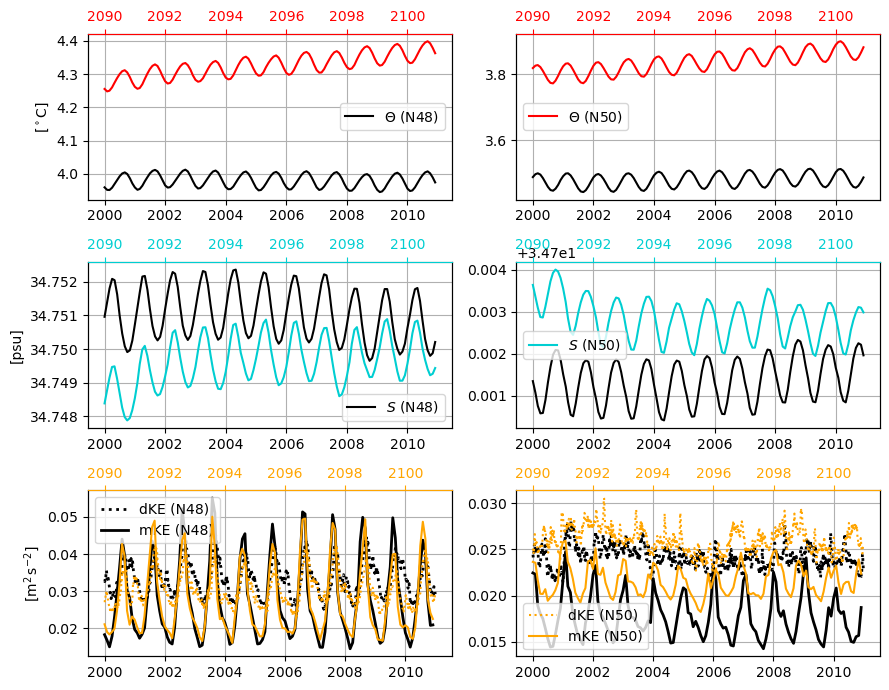

In [16]:
fig, axes = plt.subplots(figsize=(9,7), nrows=3, ncols=2)
fig.set_tight_layout(True)
ax1 = axes[0,0].twiny()
ax2 = axes[1,0].twiny()
ax3 = axes[2,0].twiny()
ax4 = axes[0,1].twiny()
ax5 = axes[1,1].twiny()
ax6 = axes[2,1].twiny()

axes[0,0].plot(tN48.time, tN48.temp, "k", label=r"$\Theta$ (N48)")
ax1.plot(tN50.time, tN50.temp, "r", label=r"$\Theta$ (N50)")

axes[1,0].plot(sN48.time, sN48.salt, "k", label=r"$S$ (N48)")
ax2.plot(sN50.time, sN50.salt, c="darkturquoise", label=r"$S$ (N50)")

axes[2,0].plot(k348.time.isel(time=slice(2,-2)), 
               k348.north.rolling(time=5).mean().dropna("time"), 
               "k:", lw=2,
               label=r"dKE (N48)"
              )
axes[2,0].plot(kN48.time, kN48.KE, "k", lw=2, label=r"mKE (N48)")
ax3.plot(k350.time.isel(time=slice(2,-2)), 
         k350.north.rolling(time=5).mean().dropna("time"), 
         c="orange", ls=":", 
         label=r"dKE (N50)"
        )
ax3.plot(kN50.time, kN50.KE, c="orange", label=r"mKE (N50)")

axes[0,1].plot(tS48.time, tS48.temp, "k", label=r"$\Theta$ (N48)")
ax4.plot(tS50.time, tS50.temp, "r", label=r"$\Theta$ (N50)")

axes[1,1].plot(sS48.time, sS48.salt, "k", label=r"$S$ (N48)")
ax5.plot(sS50.time, sS50.salt, c="darkturquoise", label=r"$S$ (N50)")

axes[2,1].plot(k348.time.isel(time=slice(2,-2)), 
               k348.south.rolling(time=5).mean().dropna("time"), 
               "k:", lw=2,
               label=r"dKE (N48)"
              )
axes[2,1].plot(kS48.time, kS48.KE, "k", lw=2, label=r"mKE (N48)")
ax6.plot(k350.time.isel(time=slice(2,-2)), 
         k350.south.rolling(time=5).mean().dropna("time"), 
         c="orange", ls=":", 
         label=r"dKE (N50)"
        )
ax6.plot(kS50.time, kS50.KE, c="orange", label=r"mKE (N50)")

axes[0,0].set_ylabel(r"[$^\circ$C]")
axes[1,0].set_ylabel(r"[psu]")
axes[2,0].set_ylabel(r"[m$^2\,$s$^{-2}$]")

ax1.xaxis.label.set_color('red')
ax2.xaxis.label.set_color('darkturquoise')
ax3.xaxis.label.set_color('orange')  

ax1.tick_params(axis='x', colors='red')
ax2.tick_params(axis='x', colors='darkturquoise')
ax3.tick_params(axis='x', colors='orange')

ax1.spines['top'].set_color('red') 
ax2.spines['top'].set_color('darkturquoise') 
ax3.spines['top'].set_color('orange') 

ax4.xaxis.label.set_color('red')
ax5.xaxis.label.set_color('darkturquoise')
ax6.xaxis.label.set_color('orange')  

ax4.tick_params(axis='x', colors='red')
ax5.tick_params(axis='x', colors='darkturquoise')
ax6.tick_params(axis='x', colors='orange')

ax4.spines['top'].set_color('red') 
ax5.spines['top'].set_color('darkturquoise') 
ax6.spines['top'].set_color('orange') 

# axes[2,0].set_zorder(ax3.get_zorder() + 1)  # ax1 on top of ax2
# axes[2,0].patch.set_visible(False)  # Hide ax1 background so ax2 shows through

axes[0,0].legend(loc="center right")
ax4.legend(loc="center left")
axes[1,0].legend(loc="lower right")
ax5.legend(loc="center left")
axes[2,0].legend(loc="upper left")
ax6.legend(loc="lower left")

axes[0,0].grid(True)
axes[1,0].grid(True)
axes[2,0].grid(True)
axes[0,1].grid(True)
axes[1,1].grid(True)
axes[2,1].grid(True)
plt.savefig(op.join(wdir, '../../Figs/next/timeseries_N48-N50.pdf'))